# 1. Data Diagnosis
First we will try to look at the raw data provided and determine all the fields that require transformation, where data is blank or null

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mat
import seaborn as sns

from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(ROOT)

C:\Users\prana\Study\Home Assignment - Technology Band III\customer_churn_project


In [2]:
df = pd.read_csv(ROOT/ "data/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Data Types and structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df_structure = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nulls': df.isna().sum(),
    'unique':df.nunique(),
    'sample_values': [df[x].dropna().iloc[0] for x in df.columns],
})
df_structure

,data_type,non_null,nulls,unique,sample_values
customerID,str,7043,0,7043,7590-VHVEG
gender,str,7043,0,2,Female
SeniorCitizen,int64,7043,0,2,0
Partner,str,7043,0,2,Yes
Dependents,str,7043,0,2,No
tenure,int64,7043,0,73,1
PhoneService,str,7043,0,2,No
MultipleLines,str,7043,0,3,No phone service
InternetService,str,7043,0,3,DSL
OnlineSecurity,str,7043,0,3,No


**Observation** - Total Charge column is stored as string not a number, even though in dictionary its mentioned numerical.

**Attempt**: We will try to convert this to number and see if any value causes problem

In [5]:
numeric_total_charge = pd.to_numeric(df['TotalCharges'], errors='coerce')
bad_data = df.loc[numeric_total_charge.isna(), ['customerID','tenure', 'TotalCharges', 'Churn']]
print(f"Rows where TotalCharge will not parse: {len(bad_data)}")
print(f"Their tenure and churn values: {sorted(bad_data['tenure'].unique())}  {bad_data['Churn'].unique().tolist()})")

Rows where TotalCharge will not parse: 11
Their tenure and churn values: [np.int64(0)]  ['No'])


In [6]:
bad_data.head(11)

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


**Observation** - We found all data present is getting converted to number. There are `11 blank Total Charges`.

These dont appear random noise, but is legit data. Each customer has `tenure=0`, meaning a brand new customre that has not been through a billing. They also have `Churn=No`, as they are newly joined.

**Decision** Fill these blanks with `0.0`. No need to drop these or use any median value for them.  
**Reasoning** 
 - Dropping these values, will cause an entire segment of `brand new account` from training.
 - Using median value, will create insignificant billing history for customers having no bill.

This is implemented in `RawCleaner` inside the chunk_pipeline, so an API request treats new customer as well with behavior.


## Missing Value analysis

In [7]:
blank_values = df.replace(r"^\s*$", np.nan, regex=True)
missing = pd.DataFrame({
    "nulls": blank_values.isna().sum()
})
missing[missing["nulls"] > 0]

,nulls
TotalCharges,11


**Observation** Only TotalCharges as blank or missing value which has already been replaced by 0

## Duplicate analysis

In [8]:
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate customer ID : {df['customerID'].duplicated().sum()}")
print(f"Identical feature rows : {df.drop(columns='customerID').duplicated().sum()}")

Duplicate Rows: 0
Duplicate customer ID : 0
Identical feature rows : 22


**Observation** - There is no duplicate customer IDs. Each row represents unique customer. There are few identical feature profiles, 
but since customerID are different, these are genuine different customer have same packages

**Decision** - No handling required

## Numerical and Categorical Features

In [9]:
target_id = "Churn"
id_col = "customerID"

# TotalCharges can be treated as numeric from here on(it will in the pipeline)

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_id, id_col]]

print(f"Numeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

df_num = df.copy()
df_num["TotalCharges"] = numeric_total_charge
df_num[numeric_cols].describe().T

Numeric Columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


## Encoding Categorical variables

In [10]:
# Check cardinality of categorical columns, to see there is some special handling required

cat_card = pd.DataFrame({
    "unique_value_count" : [df[c].nunique() for c in categorical_cols],
    "unique_values":[", ".join(map(str, sorted(df[c].unique()))) for c in categorical_cols],
}, index=categorical_cols)

cat_card

,unique_value_count,unique_values
gender,2,"Female, Male"
Partner,2,"No, Yes"
Dependents,2,"No, Yes"
PhoneService,2,"No, Yes"
MultipleLines,3,"No, No phone service, Yes"
InternetService,3,"DSL, Fiber optic, No"
OnlineSecurity,3,"No, No internet service, Yes"
OnlineBackup,3,"No, No internet service, Yes"
DeviceProtection,3,"No, No internet service, Yes"
TechSupport,3,"No, No internet service, Yes"


**Observation** - `No internet Service` is a 3rd value present in Six service columns(`OnlineSecurity`, `OnlineBackup`,`DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`)

We will check for any one column how much relevant data does the 3rd value hold.

In [11]:
df['Churned'] = (df['Churn'] == 'Yes').astype(int)
df.head()
out = df.groupby('OnlineSecurity', observed=True)['Churned'].agg(customers="size", churn_rate="mean")
out

,customers,churn_rate
OnlineSecurity,,
No,3498,0.417667
No internet service,1526,0.074050
Yes,2019,0.146112


In [12]:
merge_online_no = df['OnlineSecurity'].replace('No internet service', 'No')
out_2 = df.groupby(merge_online_no, observed=True)['Churned'].agg(customers="size", churn_rate="mean")
out_2

,customers,churn_rate
OnlineSecurity,,
No,5024,0.313296
Yes,2019,0.146112


**Analysis** - Merging the 3rd parameter into No, drops the 27point(42% vs 14.7%) difference between NO and YES to 17 
point(31% vs 14.7%).

**Decision** - The 3rd value will be kept as its own level and not collapse into `No`. All categoricals are low-cardinality(2-4 values), so one hot encoding is safe

## Target Variable Analysis

In [13]:
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True)*100
print(churn_counts.to_string())
print(churn_percentage.to_string())

print(f"\n Ratio (No:Yes) = {churn_counts['No'] / churn_counts['Yes']:.2f} :1")

Churn
No     5174
Yes    1869
Churn
No     73.463013
Yes    26.536987

 Ratio (No:Yes) = 2.77 :1


**Observation** - moderate class imbalance.
The data is imbalanced, a model that predicts `No` for every single customer scores `73.5% accuracy` while catching zero churners.
Accuracy alone is misleading. We need to judge model on recall, precision and F1 with accuracy reported alongside. 

**Decision**
the data is *not* extermely imbalanced. We will be using `class-weight='balanced` and also doing `decision-threshold tuning`.

## Train / Test Data Split

In [14]:
from sklearn.model_selection import train_test_split
from churn_pipeline import RAW_FEATURES

target = 'Churn'

X = df[RAW_FEATURES].copy()
Y = (df[target] == 'Yes').astype(int)   # getting posivite churned

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

print(f"Training data: {X_train.shape[0]:,} rows ({Y_train.mean():.2%} churn)")
print(f"Test data: {X_test.shape[0]:,} rows ({Y_test.mean():.2%} churn)")
print(f"Features passed to pipelin: {len(RAW_FEATURES)} ")

Training data: 4,930 rows (26.53% churn)
Test data: 2,113 rows (26.55% churn)
Features passed to pipelin: 19 


# Data Preprocession decisions

| Item | Decision | Reason |
|---|---|---|
| `TotalCharges` type | Text has been converted to numeric inside the pipeline | Data is coming string |
| `11 blank TotalCharges` | Fill with `0.0` | Dropping would delete genuine new-customer segment |
| `customerID` | Dropped | Just unique identifier, no feature |
| `No internet service` | Kept as its own category | Adding it to `NO` was decreasing the point difference |
| `Categorical encoding` | One-hot, `handle-unknown='ignore'` | Low cardinality |


## Important Note
All of the above preprocessing steps are defined and catered in **churn_pipeline** so that the same steps can be applied
to any new input coming from API. The notebook imports that module rather than transforming data inline. This way same logic is applied 
to both productiona and test data.

The pipeline is defined once and used everywhere for all common logic:
`RawCleaner -> FeatureEngineer -> ColumnTransformer -> Classifier`

---

# 2. Exploratory Data Analysis

We run this on training data only. This will help decide the fetaures to plot are correct when when model runs on test data

In [15]:
from churn_pipeline import RawCleaner, FeatureEngineer, ADDON_SERVICES
from matplotlib.colors import LinearSegmentedColormap

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
CHURN_COLORS = {"No": BLUE, "Yes": ORANGE}
DIVERGING = LinearSegmentedColormap.from_list("blue_red", ["#2a78d6", "#f0efec", "#d03b3b"])
SEQ_BLUE = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#2a78d6", "#0d366b"])

# A cleaned, human-readable view of the TRAINING data for plotting only.
eda = RawCleaner().fit_transform(X_train)

# Add churn to the plotting data for data present in Training Data
eda["Churn"] = np.where(Y_train.loc[eda.index] == 1, "Yes", "No")

BASE_RATE = (eda["Churn"] == "Yes").mean()
print((eda["Churn"]).value_counts())
print(f"Training-set churn rate (the baseline every chart is read against): {BASE_RATE:.1%}")

Churn
No     3622
Yes    1308
Name: count, dtype: int64
Training-set churn rate (the baseline every chart is read against): 26.5%


In [16]:
#  Churn rate and volume for each level of a categorical column.
def churn_rate_by(col, data=eda):
    g = data.groupby(col, observed=True)["Churn"]
    out = pd.DataFrame({"customers": g.size(), "churn_rate": g.apply(lambda s: (s == "Yes").mean())})
    return out.sort_values("churn_rate", ascending=False)

# Horizontal churn-rate bars with direct labels and a base-rate reference line.
def rate_bars(ax, table, title, xlabel="Churn rate", color=BLUE):
    y_pos = np.arange(len(table))[::-1]
    ax.barh(y_pos, table["churn_rate"] * 100, color=color, height=0.62, zorder=3)
    ax.axvline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.2, zorder=4)
    ax.set_yticks(y_pos, table.index.astype(str))
    for yy, (rate, n) in zip(y_pos, zip(table["churn_rate"], table["customers"])):
        ax.text(rate * 100 + 0.8, yy, f"{rate:.1%}  (n={n:,})", va="center",
                fontsize=9, color=INK_2)
    ax.set_xlim(0, max(60, table["churn_rate"].max() * 100 * 1.35))
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left")
    ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

### Churn Distribution

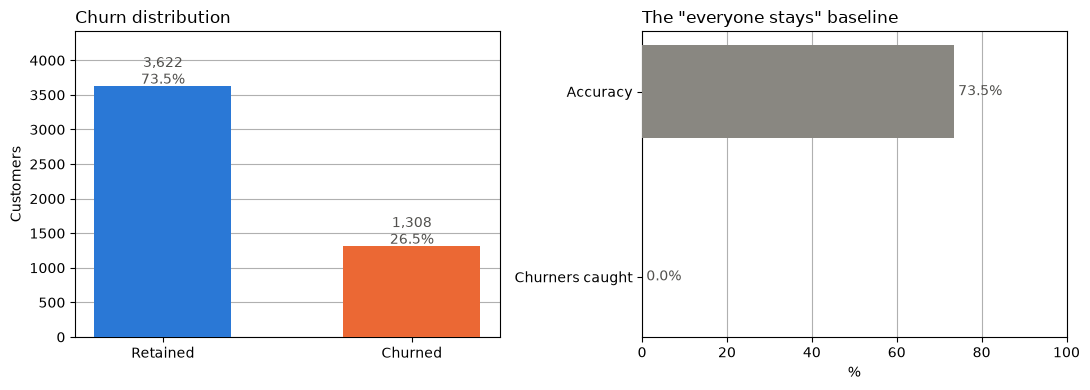

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = eda["Churn"].value_counts().reindex(["No", "Yes"])
bars = axes[0].bar(["Retained", "Churned"], counts.values,
                   color=[BLUE, ORANGE], width=0.55, zorder=3)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 40, f"{v:,}\n{v / counts.sum():.1%}",
                 ha="center", fontsize=10, color=INK_2)
axes[0].set_ylim(0, counts.max() * 1.22)
axes[0].set_ylabel("Customers"); axes[0].set_title("Churn distribution", loc="left")
axes[0].yaxis.grid(True, zorder=0); axes[0].set_axisbelow(True)

# What a 'predict everyone stays' model would score — the bar any model must clear.
axes[1].barh([1, 0], [counts["No"] / counts.sum() * 100, 0.0], color=[MUTED, ORANGE],
             height=0.5, zorder=3)
axes[1].set_yticks([1, 0], ["Accuracy", "Churners caught"])
axes[1].text(counts["No"] / counts.sum() * 100 + 1, 1, f"{counts['No'] / counts.sum():.1%}",
             va="center", color=INK_2, fontsize=10)
axes[1].text(1, 0, "0.0%", va="center", color=INK_2, fontsize=10)
axes[1].set_xlim(0, 100); axes[1].set_xlabel("%")
axes[1].set_title('The "everyone stays" baseline', loc="left")
axes[1].xaxis.grid(True, zorder=0); axes[1].set_axisbelow(True)

plt.tight_layout();
plt.show()

**Insight** Roughly 1 in 4 customers Churn. The right-panel is the reason accuracy is not main metric.
A model that predicts "nobody churns" already scores 73.5% accuracy while identifying **zero** at-risk customers and
delivering nothing to the retention team. Every model below has to be judged on how many real churners it finds.

## Contract type 

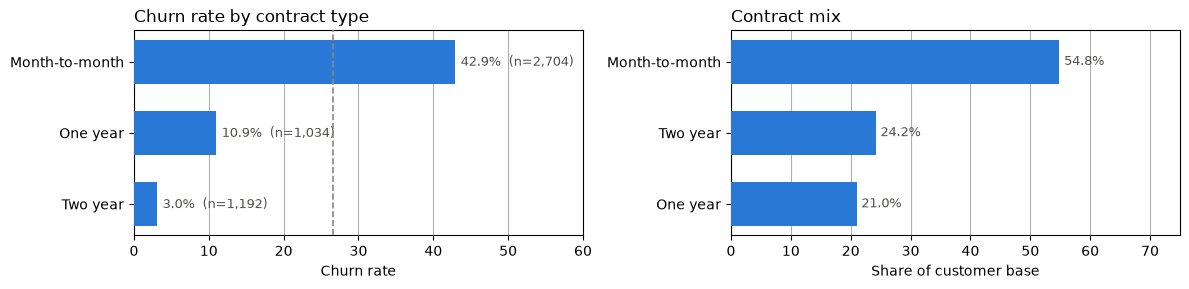

,customers,churn_rate
Contract,,
Month-to-month,2704,42.9
One year,1034,10.9
Two year,1192,3.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
rate_bars(axes[0], churn_rate_by("Contract"), "Churn rate by contract type")

# Contract mix: how much of the base sits in the risky bucket
mix = eda["Contract"].value_counts(normalize=True).sort_values()
axes[1].barh(np.arange(len(mix)), mix.values * 100, color=BLUE, height=0.62, zorder=3)
axes[1].set_yticks(np.arange(len(mix)), mix.index)
for i, v in enumerate(mix.values):
    axes[1].text(v * 100 + 0.8, i, f"{v:.1%}", va="center", fontsize=9, color=INK_2)
axes[1].set_xlim(0, 75); axes[1].set_xlabel("Share of customer base")
axes[1].set_title("Contract mix", loc="left")
axes[1].xaxis.grid(True, zorder=0); axes[1].set_axisbelow(True)

plt.tight_layout();
plt.show()
churn_rate_by("Contract").assign(churn_rate=lambda d: (d.churn_rate * 100).round(1))

**Insight** — this is the finding with the clearest commercial action.

Month-to-month customers churn at roughly **43%**, against about **11%** on one-year and **3%** on
two-year contracts: a ~14× spread. **over half the customer base** sits on month-to-month.

The dashed line on every chart in this section is the 26.5% overall churn rate, so a bar's distance
from it is the size of the effect.

**NOTE**: a targeted incentive to move month-to-month customers onto an annual 
contract addresses the largest and riskiest block of the base at once.

## Service type and payment method

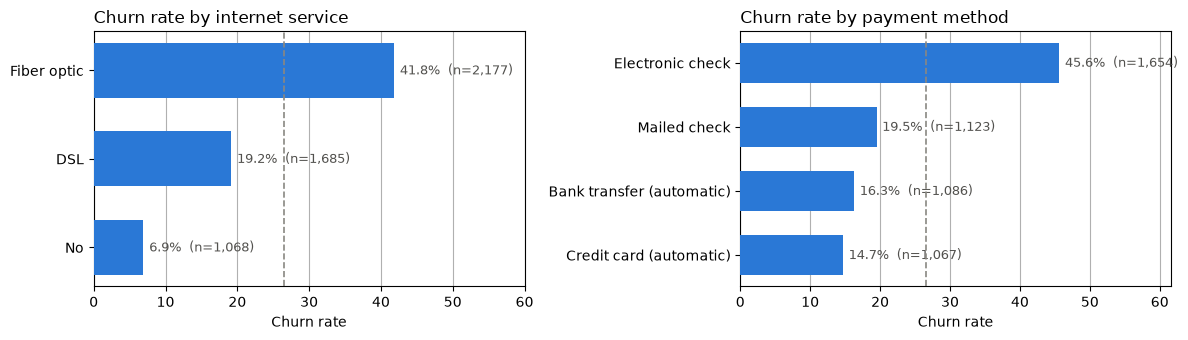

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
rate_bars(axes[0], churn_rate_by("InternetService"), "Churn rate by internet service")
rate_bars(axes[1], churn_rate_by("PaymentMethod"), "Churn rate by payment method")
plt.tight_layout();
plt.show()

**Insights**

`Fibre optic is the problem product.` Fibre customers churn at about **42%**, roughly triple the
**7%** of customers with no internet at all, and well above DSL's ~19%. It points at a
price-versus-experience gap: the service is not delivering against what it costs. Worth a service-quality
investigation, not just a discount.

`Electronic check is a behavioural red flag.` Electronic-check payers churn at roughly **45%**,
against ~15–17% for the two automatic methods. The payment method is unlikely to *cause* churn;
rather, a customer who never set up automatic payment has never committed, and re-authorises the
relationship every single month. Automatic payment help in retention — moving
customers onto it is a second concrete lever.

## Tenure - when customers leave

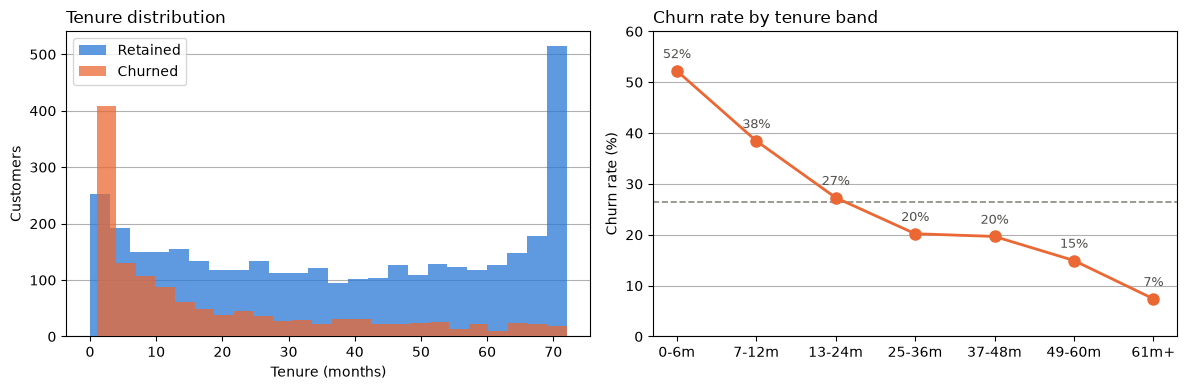

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label in ["No", "Yes"]:
    axes[0].hist(eda.loc[eda["Churn"] == label, "tenure"], bins=24, alpha=0.75,
                 color=CHURN_COLORS[label], label={"No": "Retained", "Yes": "Churned"}[label],
                 zorder=3)
axes[0].set_xlabel("Tenure (months)"); axes[0].set_ylabel("Customers")
axes[0].set_title("Tenure distribution", loc="left"); axes[0].legend()
axes[0].yaxis.grid(True, zorder=0); axes[0].set_axisbelow(True)

# Churn rate by tenure band — the survival view
bands = pd.cut(eda["tenure"], bins=[-0.1, 6, 12, 24, 36, 48, 60, 100],
               labels=["0-6m", "7-12m", "13-24m", "25-36m", "37-48m", "49-60m", "61m+"])
band_rate = eda.assign(band=bands).groupby("band", observed=True)["Churn"].apply(
    lambda s: (s == "Yes").mean())
axes[1].plot(range(len(band_rate)), band_rate.values * 100, color=ORANGE, lw=2,
             marker="o", ms=8, zorder=3)
for i, v in enumerate(band_rate.values):
    axes[1].text(i, v * 100 + 2.5, f"{v:.0%}", ha="center", fontsize=9, color=INK_2)
axes[1].axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.2)
axes[1].set_xticks(range(len(band_rate)), band_rate.index.astype(str))
axes[1].set_ylim(0, 60); axes[1].set_ylabel("Churn rate (%)")
axes[1].set_title("Churn rate by tenure band", loc="left")
axes[1].yaxis.grid(True, zorder=0); axes[1].set_axisbelow(True)

plt.tight_layout(); 
plt.show()

**Insight — churn is front-loaded, and the relationship is steeply non-linear.**

The churned distribution is stacked hard against the left side: customers who leave, leave *early*.
Roughly **half** of customers in their first six months churn, falling to under 10% past five years.
The retained distribution has the opposite shape, with a large spike at the 60–72 month end —
long-tenured customers are effectively locked in.

Commercially, the **first 6–12 months are the entire retention battleground**;

## Charges — how much churners pay

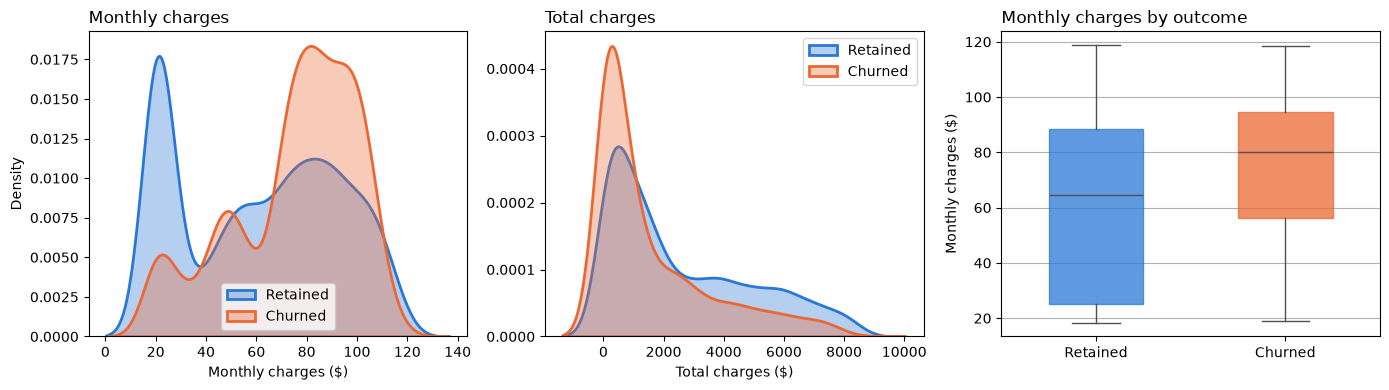

       MonthlyCharges  TotalCharges  tenure
Churn                                      
No              64.45       1673.60    38.0
Yes             80.00        705.08    10.0


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for label in ["No", "Yes"]:
    sns.kdeplot(eda.loc[eda["Churn"] == label, "MonthlyCharges"], ax=axes[0], fill=True,
                alpha=0.35, color=CHURN_COLORS[label], lw=2,
                label={"No": "Retained", "Yes": "Churned"}[label])
axes[0].set_xlabel("Monthly charges ($)"); axes[0].set_ylabel("Density")
axes[0].set_title("Monthly charges", loc="left"); axes[0].legend()

for label in ["No", "Yes"]:
    sns.kdeplot(eda.loc[eda["Churn"] == label, "TotalCharges"], ax=axes[1], fill=True,
                alpha=0.35, color=CHURN_COLORS[label], lw=2,
                label={"No": "Retained", "Yes": "Churned"}[label])
axes[1].set_xlabel("Total charges ($)"); axes[1].set_ylabel("")
axes[1].set_title("Total charges", loc="left"); axes[1].legend()

box = axes[2].boxplot(
    [eda.loc[eda["Churn"] == "No", "MonthlyCharges"], eda.loc[eda["Churn"] == "Yes", "MonthlyCharges"]],
    tick_labels=["Retained", "Churned"], patch_artist=True, widths=0.5, zorder=3)
for patch, c in zip(box["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor(c)
for el in ["medians", "whiskers", "caps"]:
    for item in box[el]:
        item.set_color(INK_2)
axes[2].set_ylabel("Monthly charges ($)")
axes[2].set_title("Monthly charges by outcome", loc="left")
axes[2].yaxis.grid(True, zorder=0); axes[2].set_axisbelow(True)

plt.tight_layout();
plt.show()

print(eda.groupby("Churn")[["MonthlyCharges", "TotalCharges", "tenure"]].median().round(2).to_string())

**Insight — high monthly bill, low lifetime value: the worst combination.**

Churners sit clearly **higher on monthly charges** (median $80 vs $64) but far **lower on total
charges** (median $705 vs $1,674). Those two facts are not in tension — they are the same fact
seen twice. Churners pay more per month (they are disproportionately on fibre and add-on-heavy
plans) but leave so early that they never accumulate spend.

The retained curve for monthly charges is bimodal: a large cluster of cheap phone-only customers
around $20 and a second premium cluster. The cheap cluster is extremely sticky. Risk concentrates
in **new, expensive customers** — which is precisely the group where an early intervention pays for
itself, because their monthly value is high.

## Tenure vs charges

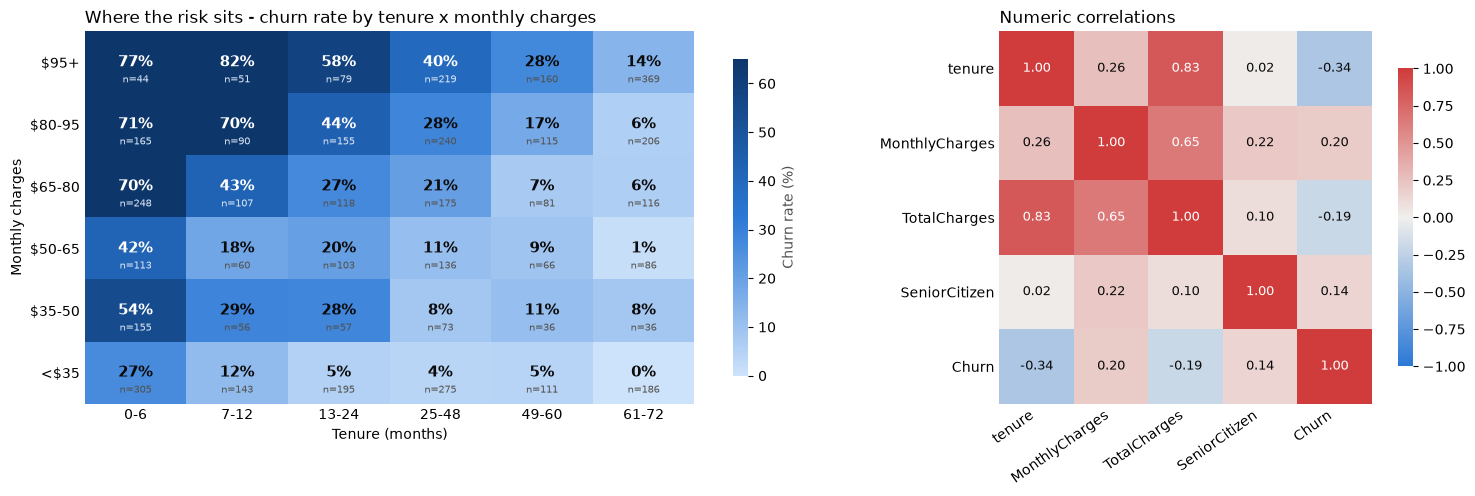

In [22]:
# A binned risk surface rather than a scatter: with 4,930 customers, overlapping
# points hide the pattern. Each cell is a segment; the number in it is that
# segment's churn rate, with its size underneath so a reader can judge reliability.
TB = [-0.1, 6, 12, 24, 48, 60, 72]
TL = ["0-6", "7-12", "13-24", "25-48", "49-60", "61-72"]
CB = [0, 35, 50, 65, 80, 95, 200]
CL = ["<$35", "$35-50", "$50-65", "$65-80", "$80-95", "$95+"]
MIN_N = 25                      # below this a cell's rate is too noisy to print

grid = eda.assign(
    _churned=(eda["Churn"] == "Yes").astype(int),
    _tb=pd.cut(eda["tenure"], TB, labels=TL),
    _cb=pd.cut(eda["MonthlyCharges"], CB, labels=CL),
)
rate = (grid.pivot_table(index="_cb", columns="_tb", values="_churned",
                         aggfunc="mean", observed=True) * 100).reindex(index=CL, columns=TL)
count = grid.pivot_table(index="_cb", columns="_tb", values="_churned",
                         aggfunc="size", observed=True).reindex(index=CL, columns=TL)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.9), width_ratios=[1.45, 1])

ax = axes[0]
im = ax.imshow(rate.where(count >= MIN_N).values, cmap=SEQ_BLUE,
               vmin=0, vmax=65, aspect="auto", origin="lower")
for i in range(len(CL)):
    for j in range(len(TL)):
        r, n = rate.iloc[i, j], count.iloc[i, j]
        if pd.isna(r) or n < MIN_N:
            ax.text(j, i, "-", ha="center", va="center", color=MUTED, fontsize=10)
            continue
        dark = r > 38                      # flip label colour for contrast
        ax.text(j, i, f"{r:.0f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white" if dark else INK)
        ax.text(j, i - 0.28, f"n={n:,}", ha="center", va="center",
                fontsize=7.5, color="#dbe7f7" if dark else INK_2)
ax.set_xticks(range(len(TL)), TL); ax.set_yticks(range(len(CL)), CL)
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Monthly charges")
ax.set_title("Where the risk sits - churn rate by tenure x monthly charges", loc="left")
ax.spines[:].set_visible(False); ax.tick_params(length=0)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Churn rate (%)", color=INK_2); cbar.outline.set_visible(False)

ax = axes[1]
corr = eda[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].assign(
    Churn=(eda["Churn"] == "Yes").astype(int)).corr()
im2 = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color=INK if abs(v) < 0.6 else "white")
ax.set_title("Numeric correlations", loc="left")
ax.spines[:].set_visible(False); ax.tick_params(length=0)
cbar2 = fig.colorbar(im2, ax=ax, shrink=0.8); cbar2.outline.set_visible(False)

plt.tight_layout(); 
plt.show()

**Insight.** `77-82%` customers in their first year paying $95+ churn at roughly three times the base rate.
82% -> 58% -> 40% -> 28% -> 14%. As the tenure grows, price does not matter. 
High price during onboarding is problem

The correlation matrix confirms `tenure` as the strongest numeric correlate of churn (≈ **−0.35**)
and shows `TotalCharges` is almost perfectly explained by `tenure × MonthlyCharges` (r ≈ 0.83 with
tenure). That redundancy is why section 3 derives a *ratio* from those columns rather than leaving
three correlated level variables to fight each other.

## Add-on services and customer profile

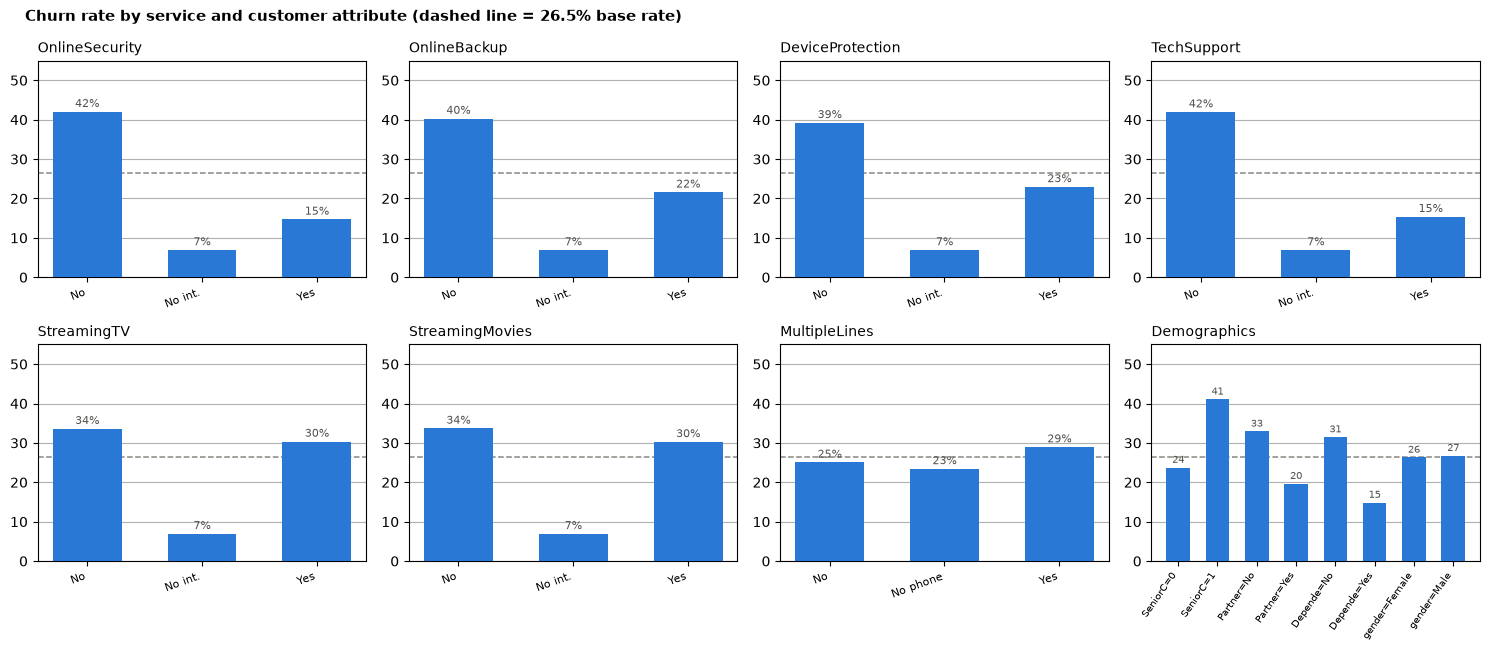

In [23]:
service_cols = ADDON_SERVICES + ["MultipleLines"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.6))
for ax, col in zip(axes.ravel(), service_cols):
    t = churn_rate_by(col).sort_index()
    ax.bar(range(len(t)), t["churn_rate"] * 100, color=BLUE, width=0.6, zorder=3)
    ax.axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.1)
    ax.set_xticks(range(len(t)),
                  [s.replace(" service", "").replace("No internet", "No int.") for s in t.index],
                  rotation=20, ha="right", fontsize=8)
    for i, v in enumerate(t["churn_rate"]):
        ax.text(i, v * 100 + 1.2, f"{v:.0%}", ha="center", fontsize=8, color=INK_2)
    ax.set_ylim(0, 55); ax.set_title(col, loc="left", fontsize=10)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# Last panel: demographic profile, flattened into one bar per attribute level
ax = axes.ravel()[7]
labels, vals = [], []
for c in ["SeniorCitizen", "Partner", "Dependents", "gender"]:
    t = churn_rate_by(c).sort_index()
    for idx, v in t["churn_rate"].items():
        labels.append(f"{c[:7]}={idx}"); vals.append(v * 100)
ax.bar(range(len(vals)), vals, color=BLUE, width=0.6, zorder=3)
ax.set_xticks(range(len(vals)), labels, rotation=55, ha="right", fontsize=7)
for i, v in enumerate(vals):
    ax.text(i, v + 1.2, f"{v:.0f}", ha="center", fontsize=7, color=INK_2)
ax.axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.1)
ax.set_ylim(0, 55); ax.set_title("Demographics", loc="left", fontsize=10)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

fig.suptitle("Churn rate by service and customer attribute (dashed line = 26.5% base rate)",
             fontsize=11, fontweight="bold", x=0.02, ha="left")
plt.tight_layout();
plt.show()

**Insight — protective add-ons, and the "No internet service" level earning its keep.**

`OnlineSecurity` and `TechSupport` services: customers who have them churn at ~15%, versus ~42% for internet customers
who declined them. 

Entertainment add-ons: `StreamingTV`, `StreamingMovies` sits at 30% with the service and 34% without. They seem to add revenue, not loyalty. That distinction matters for what a retention offer should contain: bundling *support* services is far more likely to keep a customer than bundling
*content*.

Customers with **no internet at all** churn at 6.9%, far *below* either internet group. This validates the section 1 decision to keep that level separate — collapsed into "No", it would have been averaged together with the highest-risk group and the signal would
have cancelled out.

`On demographics`: 1. senior citizens churn at 41% against 24% for everyone else, 
2. customers without a partner (33% vs 20%) or dependents (32% vs 15%) churn more. 
**Gender is inert** — 26.3% vs 26.8%, a gap of half a percentage point

---

# 3. Feature Engineering

Four features are added, all implemented in `FeatureEngineer` inside the pipeline. They are calculated per row
and it computes identically for a single customer arriving at the API.
### The features

**1. `NumAddOnServices` = count of the six optional services subscribed (0–6)**

*How.* Sum of `Yes` across `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
`StreamingTV`, `StreamingMovies`.

*Why.* A single **engagement / stickiness** score. Section 2.7 showed each service individually
lowers churn. It captures the switching-cost intuition directly: the more services a household has
wired into one provider, the more painful leaving becomes.

**2. `TenureBucket` — lifecycle stage (0–12m, 13–24m, 25–48m, 49m+)**

*How.* `tenure` binned into four lifecycle stages.

*Why.* In EDA we showed churn risk decays steeply and non-linearly with tenure. It hands the retention team a
**segment they can actually operate on** ("first-year customers") rather than a threshold in months.

**3. `AvgChargerPerMonth` = `TotalCharges/tenure` **

*How.* Total spend to date divided by months, gaurded for tenure =0 falls back to current MonthlyCharges.

*Why.* A single **engagement / stickiness** score. Section 2.7 showed each service individually
lowers churn. It captures the switching-cost intuition directly: the more services a household has
wired into one provider, the more painful leaving becomes.


In [24]:
# Apply the engineered features to the training view so we can inspect them.
eda_fe = FeatureEngineer().fit_transform(eda.drop(columns=["Churn"]))
eda_fe["Churn"] = eda["Churn"].values

print(eda_fe[["tenure", "NumAddOnServices", "TenureBucket"]].head(8).to_string())
print()
print(eda_fe.groupby("Churn")[["NumAddOnServices"]]
      .agg(["mean", "median"]).round(2).to_string())

zero = eda_fe[eda_fe['NumAddOnServices'] == 0]
no_internet = zero['InternetService'] == 'No'
print(f"Number of Add on Services == 0 bucket length {len(zero)}")
print(f"Share with no internet at all {no_internet.mean():.1%}")
print(f"Churn rate, no internet: {(zero.loc[no_internet, 'Churn'] == 'Yes').mean():.1%}")
print(f"Churn rate, has internet: {(zero.loc[~no_internet, 'Churn'] == 'Yes').mean():.1%}")

      tenure  NumAddOnServices TenureBucket
5557       5                 1        0-12m
2270       3                 2        0-12m
6930       3                 0        0-12m
2257      60                 4         49m+
898       12                 4        0-12m
3828      65                 0         49m+
2147      18                 0       13-24m
3149       8                 3        0-12m

      NumAddOnServices       
                  mean median
Churn                        
No                2.16    2.0
Yes               1.81    2.0
Number of Add on Services == 0 bucket length 1538
Share with no internet at all 69.4%
Churn rate, no internet: 6.9%
Churn rate, has internet: 51.1%


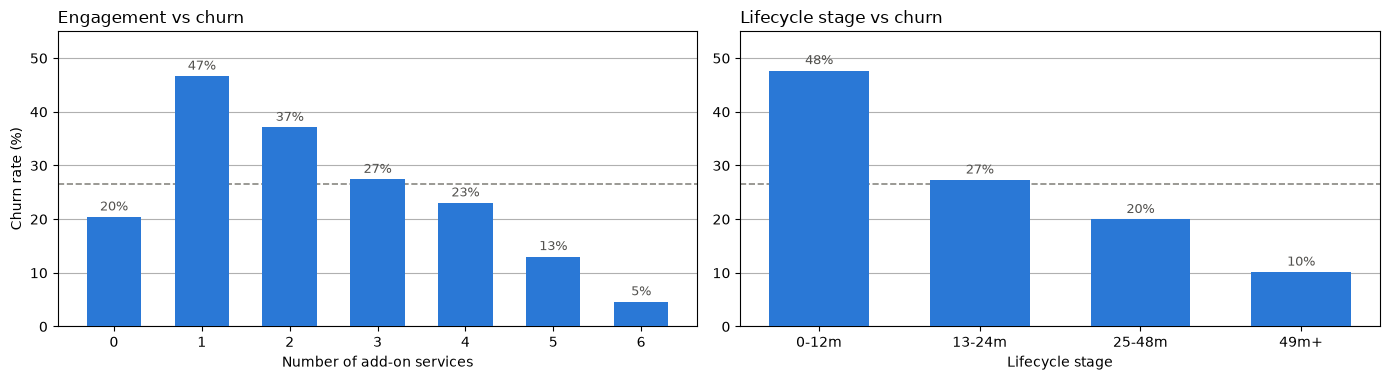

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.9))

# NumAddOnServices
t = eda_fe.groupby("NumAddOnServices", observed=True)["Churn"].apply(lambda s: (s == "Yes").mean())
n = eda_fe["NumAddOnServices"].value_counts().sort_index()
axes[0].bar(t.index, t.values * 100, color=BLUE, width=0.62, zorder=3)
for i, v in t.items():
    axes[0].text(i, v * 100 + 1.2, f"{v:.0%}", ha="center", fontsize=9, color=INK_2)
axes[0].axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.2)
axes[0].set_xlabel("Number of add-on services"); axes[0].set_ylabel("Churn rate (%)")
axes[0].set_ylim(0, 55); axes[0].set_title("Engagement vs churn", loc="left")
axes[0].yaxis.grid(True, zorder=0); axes[0].set_axisbelow(True)

# TenureBucket
order = ["0-12m", "13-24m", "25-48m", "49m+"]
t2 = eda_fe.groupby("TenureBucket", observed=True)["Churn"].apply(
    lambda s: (s == "Yes").mean()).reindex(order)
axes[1].bar(range(len(t2)), t2.values * 100, color=BLUE, width=0.62, zorder=3)
for i, v in enumerate(t2.values):
    axes[1].text(i, v * 100 + 1.2, f"{v:.0%}", ha="center", fontsize=9, color=INK_2)
axes[1].axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.2)
axes[1].set_xticks(range(len(t2)), order)
axes[1].set_ylim(0, 55); axes[1].set_xlabel("Lifecycle stage")
axes[1].set_title("Lifecycle stage vs churn", loc="left")
axes[1].yaxis.grid(True, zorder=0); axes[1].set_axisbelow(True)

plt.tight_layout();
plt.show()

**`TenureBucket` Analysis.** First-year customers churn at **47.7%**, falling to 27.3% → 19.9% → 10.1%
across the later stages. It compresses section 2.4 into four segments the retention team can operate
on, with a clean 4.7× spread from top to bottom.

**`NumAddOnServices` Analysis** From one add-on onward the decline is steep and monotonic:
**46.7% → 37.1% → 27.4% → 23.0% → 13.0% → 4.6%**. A customer with six services is ten times 
less likely to leave than one with a single service. That is the switching-cost effect, and it is strong.

**69% of customers with zero add-ons have no internet service at all**, so they *cannot* buy any of the six. 
That bucket therefore mixes two opposite populations — sticky phone-only customers and disengaged internet customers. The count alone can't
separate them, which is exactly why `InternetService` stays in the model beside it.

---

# 4. Model Development

In [26]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             average_precision_score, precision_recall_curve)
from sklearn.inspection import permutation_importance

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ["accuracy", "precision", "recall", "f1"]

def cv_report(name, estimator, X=X_train, y=Y_train):
    """5-fold CV on the training split; also returns the in-sample score to expose overfitting."""
    res = cross_validate(estimator, X, y, cv=CV, scoring=SCORING,
                         return_train_score=True, n_jobs=-1)
    return {
        "model": name,
        "cv_accuracy": res["test_accuracy"].mean(),
        "cv_precision": res["test_precision"].mean(),
        "cv_recall": res["test_recall"].mean(),
        "cv_f1": res["test_f1"].mean(),
        "cv_f1_std": res["test_f1"].std(),
        "cv_recall_std": res["test_recall"].std(),
        "train_f1": res["train_f1"].mean(),
        "overfit_gap": res["train_f1"].mean() - res["test_f1"].mean(),
    }
    
results = []

## Configuration A — default Decision Tree

No constraints at all: the tree grows until every leaf is pure. Included deliberately as the
*wrong* answer, to quantify what unconstrained depth costs.

In [27]:
from churn_pipeline import build_pipeline

tree_a = build_pipeline(DecisionTreeClassifier(random_state=42))
results.append(cv_report("A · Default tree (unconstrained)", tree_a))
tree_a.fit(X_train, Y_train)
depth_a = tree_a.named_steps["model"].get_depth()
leaves_a = tree_a.named_steps["model"].get_n_leaves()
r = results[-1]
print(f" Depth: {depth_a}   Leaves: {leaves_a}")
print(f" Training accuracy: {tree_a.score(X_train, Y_train):.4f}")
print(f" CV precision : {r['cv_precision']:.4f}   CV Recall F1:  {r['cv_recall']:.4f}   CV F1:  {r['cv_f1']:.4f}")
print(f" Train F1: {r['train_f1']:.4f}   overfit gap {r['overfit_gap']:.4f}")

 Depth: 23   Leaves: 936
 Training accuracy: 0.9980
 CV precision : 0.5000   CV Recall F1:  0.5230   CV F1:  0.5110
 Train F1: 0.9967   overfit gap 0.4857


**Observation.** The unconstrained tree grows to **23 levels and 936 leaves**, with **99.8% accuracy** 
while its cross-validated F1 collapses to **0.51**. The train/CV
gap of **0.49 F1** is  overfitting: with 859 leaves over 4,930 training rows, many leaves
hold a handful of customers and describe noise rather than a pattern.

## Configuration B — constrained and imbalance-aware

Depth and leaf size capped so each leaf has to be supported by real evidence, plus
`class_weight='balanced'` so the 26.5% minority class is not steamrolled by the majority.

In [28]:
tree_b = build_pipeline(DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=50, min_samples_split=20,
    class_weight="balanced", random_state=42))
results.append(cv_report("B · Constrained + balanced", tree_b))
r1 = results[-1]
print(f" Training accuracy: {tree_a.score(X_train, Y_train):.4f}")
print(f" CV precision : {r1['cv_precision']:.4f}   CV Recall F1:  {r1['cv_recall']:.4f}   CV F1:  {r1['cv_f1']:.4f}")
print(f" Train F1: {r1['train_f1']:.4f}   overfit gap {r1['overfit_gap']:.4f}")

 Training accuracy: 0.9980
 CV precision : 0.5000   CV Recall F1:  0.7798   CV F1:  0.6089
 Train F1: 0.6356   overfit gap 0.0267


**Observation.** Constraining the tree lifts cross-validated recall by more than half — **0.51 →
0.78** — and F1 from 0.51 to 0.61, while the train/CV gap collapses from 0.49 to **0.03**.

## Configuration C — tuned Decision Tree (grid search)

Rather than hand-picking the constraints, search them. 144 combinations × 5 folds, scored on F1.
`class_weight` is included as a hyperparameter so the imbalance handling is *chosen on evidence*
rather than assumed.

In [29]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_leaf": [10, 20, 50],
    "model__class_weight": [None, "balanced"],
    "model__min_samples_split": [2, 20],
}

grid = GridSearchCV(
    build_pipeline(DecisionTreeClassifier(random_state=42)),
    param_grid, scoring="f1", cv=CV, n_jobs=-1, refit=True, verbose=0,
)
grid.fit(X_train, Y_train)

print(f"Combinations searched: {len(grid.cv_results_['params'])}")
print(f"Best CV F1: {grid.best_score_:.4f}")
print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"   {k.replace('model__', '')}: {v}")

tree_c = grid.best_estimator_
results.append(cv_report("C · Tuned tree (GridSearchCV)", tree_c))
r2 = results[-1]
print(f" Training accuracy: {tree_a.score(X_train, Y_train):.4f}")
print(f" CV precision : {r2['cv_precision']:.4f}   CV Recall F1:  {r2['cv_recall']:.4f}   CV F1:  {r2['cv_f1']:.4f}")
print(f" Train F1: {r2['train_f1']:.4f}   overfit gap {r2['overfit_gap']:.4f}")

Combinations searched: 144
Best CV F1: 0.6145
Best parameters:
   class_weight: balanced
   criterion: entropy
   max_depth: 10
   min_samples_leaf: 50
   min_samples_split: 2
 Training accuracy: 0.9980
 CV precision : 0.5112   CV Recall F1:  0.7714   CV F1:  0.6145
 Train F1: 0.6515   overfit gap 0.0369


In [30]:
# Checking how the best params where decided

cvres = pd.DataFrame(grid.cv_results_)
top5 = cvres.nlargest(5, "mean_test_score")[
    ["param_model__criterion", "param_model__max_depth", "param_model__min_samples_leaf",
     "param_model__class_weight", "mean_test_score", "std_test_score"]
].rename(columns=lambda c: c.replace("param_model__", ""))
top5.round(4).reset_index(drop=True)

,criterion,max_depth,min_samples_leaf,class_weight,mean_test_score,std_test_score
0,entropy,10,50,balanced,0.6145,0.0186
1,entropy,10,50,balanced,0.6145,0.0186
2,entropy,4,50,balanced,0.6145,0.0148
3,entropy,4,50,balanced,0.6145,0.0148
4,entropy,4,10,balanced,0.6141,0.0151


## Random Forest - Bonus Part
Will not be used for Model Comparison. Only for Benchmarking

In [31]:
rf_grid = GridSearchCV(
    build_pipeline(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    {
        "model__max_depth": [8, 12],
        "model__min_samples_leaf": [5, 10],
        "model__class_weight": [None, "balanced"],
    },
    scoring="f1", cv=CV, n_jobs=-1, refit=True,
)
rf_grid.fit(X_train, Y_train)
forest = rf_grid.best_estimator_

print(f"Best CV F1: {rf_grid.best_score_:.4f}")
print("Best parameters:", {k.replace("model__", ""): v for k, v in rf_grid.best_params_.items()})

Best CV F1: 0.6323
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 5}


## Model comparison

In [32]:
comparison = pd.DataFrame(results).set_index("model")
display_cols = ["cv_accuracy", "cv_precision", "cv_recall", "cv_f1", "train_f1", "overfit_gap"]
comparison[display_cols].round(4)

,cv_accuracy,cv_precision,cv_recall,cv_f1,train_f1,overfit_gap
model,,,,,,
A · Default tree (unconstrained),0.7345,0.5000,0.5230,0.5110,0.9967,0.4857
B · Constrained + balanced,0.7339,0.5000,0.7798,0.6089,0.6356,0.0267
C · Tuned tree (GridSearchCV),0.7430,0.5112,0.7714,0.6145,0.6515,0.0369


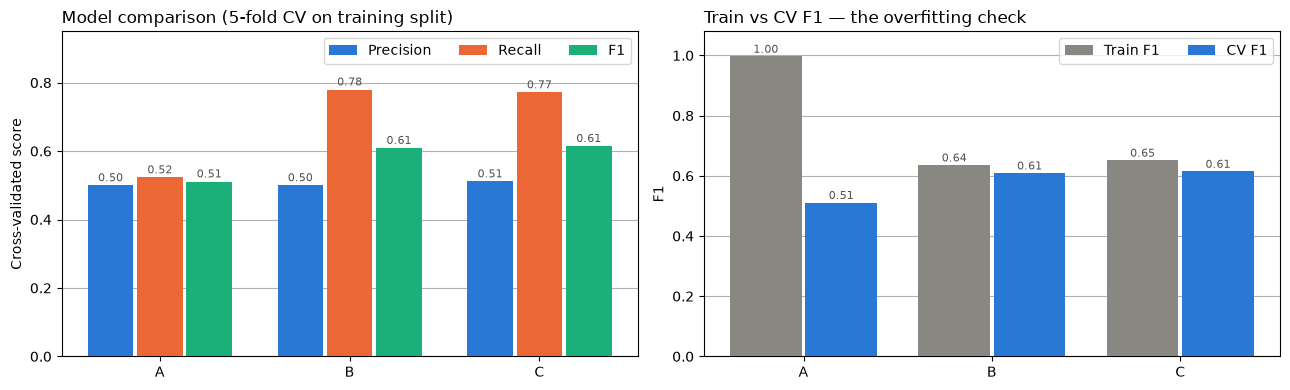

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metrics = ["cv_precision", "cv_recall", "cv_f1"]
labels = ["Precision", "Recall", "F1"]
xs = np.arange(len(comparison)); w = 0.26
for i, (m, lab, c) in enumerate(zip(metrics, labels, [BLUE, ORANGE, AQUA])):
    axes[0].bar(xs + (i - 1) * w, comparison[m], width=w - 0.02, label=lab, color=c, zorder=3)
    for x, v in zip(xs + (i - 1) * w, comparison[m]):
        axes[0].text(x, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=INK_2)
axes[0].set_xticks(xs, [m.split(" · ")[0] for m in comparison.index])
axes[0].set_ylim(0, 0.95); axes[0].set_ylabel("Cross-validated score")
axes[0].set_title("Model comparison (5-fold CV on training split)", loc="left")
axes[0].legend(ncol=3); axes[0].yaxis.grid(True, zorder=0); axes[0].set_axisbelow(True)

axes[1].bar(xs, comparison["train_f1"], width=0.38, label="Train F1", color=MUTED, zorder=3)
axes[1].bar(xs + 0.4, comparison["cv_f1"], width=0.38, label="CV F1", color=BLUE, zorder=3)
for x, v in zip(xs, comparison["train_f1"]):
    axes[1].text(x, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=INK_2)
for x, v in zip(xs + 0.4, comparison["cv_f1"]):
    axes[1].text(x, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=INK_2)
axes[1].set_xticks(xs + 0.2, [m.split(" · ")[0] for m in comparison.index])
axes[1].set_ylim(0, 1.08); axes[1].set_ylabel("F1")
axes[1].set_title("Train vs CV F1 — the overfitting check", loc="left")
axes[1].legend(ncol=2); axes[1].yaxis.grid(True, zorder=0); axes[1].set_axisbelow(True)

plt.tight_layout();
plt.show()

In [34]:
fold_b = cross_validate(tree_b, X_train, Y_train, cv=CV, scoring=["recall", "f1"], n_jobs=-1)
fold_c = cross_validate(tree_c, X_train, Y_train, cv=CV, scoring=["recall", "f1"], n_jobs=-1)

fold_cmp = pd.DataFrame({
    "B recall": fold_b["test_recall"], "C recall": fold_c["test_recall"],
    "recall B-C": fold_b["test_recall"] - fold_c["test_recall"],
    "B F1": fold_b["test_f1"], "C F1": fold_c["test_f1"],
    "F1 B-C": fold_b["test_f1"] - fold_c["test_f1"],
}, index=[f"fold {i + 1}" for i in range(CV.get_n_splits())])
fold_cmp.loc["mean"] = fold_cmp.mean()

print(f"B wins recall in {(fold_cmp['recall B-C'][:-1] > 0).sum()} of 5 folds")
print(f"C wins F1     in {(fold_cmp['F1 B-C'][:-1] < 0).sum()} of 5 folds")
fold_cmp.round(4)

B wins recall in 2 of 5 folds
C wins F1     in 3 of 5 folds


,B recall,C recall,recall B-C,B F1,C F1,F1 B-C
fold 1,0.7356,0.7433,-0.0077,0.5972,0.5933,0.0039
fold 2,0.7893,0.7893,0.0000,0.6417,0.6388,0.0030
fold 3,0.7710,0.7977,-0.0267,0.5864,0.6006,-0.0142
fold 4,0.7710,0.7405,0.0305,0.5855,0.6053,-0.0198
fold 5,0.8321,0.7863,0.0458,0.6337,0.6348,-0.0011
mean,0.7798,0.7714,0.0084,0.6089,0.6145,-0.0056


## 4.3 Final model selection and justification

**Selected: Configuration C — the grid-searched tree** (`entropy`, `max_depth=10`,
`min_samples_leaf=50`, `min_sample_split=2`, `class_weight='balanced'`).

*Why not A.* Disqualified on the evidence: near-perfect training accuracy with the worst
cross-validated F1 of the four, and recall of 0.51 — it misses half the churners.

*Why C over B.* C has clearly better recall when compared across the 5 folds and F1  as well. When tried reshuffling the folds, the results were still in favor of C. We are preferring `Recall` as missing one churner costs more than false alarm. More details in later section.

----

In [35]:
FINAL_MODEL = tree_c
final_tree = FINAL_MODEL.named_steps["model"]
print("Final model:", type(final_tree).__name__)
print(f"Depth: {final_tree.get_depth()}   Leaves: {final_tree.get_n_leaves()}")
print("Hyperparameters:")
for k in ["criterion", "max_depth", "min_samples_leaf", "min_samples_split", "class_weight"]:
    print(f"   {k}: {final_tree.get_params()[k]}")

Final model: DecisionTreeClassifier
Depth: 9   Leaves: 71
Hyperparameters:
   criterion: entropy
   max_depth: 10
   min_samples_leaf: 50
   min_samples_split: 2
   class_weight: balanced


# 5. Model Evaluation

The test set is opened here for the first time. It has been untouched through cleaning, EDA, feature
design, hyperparameter search and model selection.

In [36]:
def evaluate(model, X, y, threshold=0.5, label=""):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "model": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
    }

test_rows = [
    evaluate(FINAL_MODEL, X_test, Y_test, 0.50, "C · Final Decision Tree  <- shipped")
]
test_results = pd.DataFrame(test_rows).set_index("model")
test_results.round(4)

,threshold,accuracy,precision,recall,f1
model,,,,,
C · Final Decision Tree <- shipped,0.5,0.7336,0.4989,0.7736,0.6066


**Result** Cross-validation on the training split predicted accuracy 0.733,
precision 0.5, recall 0.777 and F1 0.607. The test set — 2,113 customers the model has never seen.

In [37]:
y_proba = FINAL_MODEL.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print(f"FINAL MODEL — grid-searched Decision Tree")
print("=" * 58)
print(f"Accuracy : {accuracy_score(Y_test, y_pred):.4f}")
print(f"Precision: {precision_score(Y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(Y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(Y_test, y_pred):.4f}")
print()
print(classification_report(Y_test, y_pred, target_names=["Retained (0)", "Churned (1)"], digits=3))

FINAL MODEL — grid-searched Decision Tree
Accuracy : 0.7336
Precision: 0.4989
Recall   : 0.7736
F1 Score : 0.6066

              precision    recall  f1-score   support

Retained (0)      0.898     0.719     0.799      1552
 Churned (1)      0.499     0.774     0.607       561

    accuracy                          0.734      2113
   macro avg      0.698     0.746     0.703      2113
weighted avg      0.792     0.734     0.748      2113



## Confusion Matrix

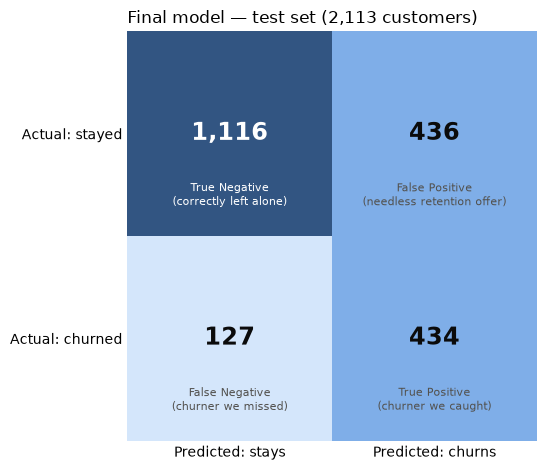

caught 434 of 561 real churners (77.4%), missed 127
raised 870 alerts, of which 436 were false alarms (50.1% of alerts, 41.2% of the base)
left 1116 loyal customers alone correctly


In [38]:
def plot_cm(ax, cm, title):
    ax.imshow(cm, cmap=SEQ_BLUE, alpha=0.85)
    labels = [["True Negative\n(correctly left alone)", "False Positive\n(needless retention offer)"],
              ["False Negative\n(churner we missed)", "True Positive\n(churner we caught)"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=17,
                    fontweight="bold", color="white" if cm[i, j] > cm.max() * 0.55 else INK)
            ax.text(j, i + 0.30, labels[i][j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() * 0.55 else INK_2)
    ax.set_xticks([0, 1], ["Predicted: stays", "Predicted: churns"])
    ax.set_yticks([0, 1], ["Actual: stayed", "Actual: churned"])
    ax.set_title(title, loc="left"); ax.spines[:].set_visible(False)
    ax.tick_params(length=0)

cm_final = confusion_matrix(Y_test, y_pred)

fig, ax = plt.subplots(figsize=(6.6, 4.8))
plot_cm(ax, cm_final, "Final model — test set (2,113 customers)")
plt.tight_layout(); 
plt.show()

tn, fp, fn, tp = cm_final.ravel()
print(f"caught {tp} of {tp + fn} real churners ({tp / (tp + fn):.1%}), missed {fn}")
print(f"raised {tp + fp} alerts, of which {fp} were false alarms "
      f"({fp / (tp + fp):.1%} of alerts, {(tp + fp) / cm_final.sum():.1%} of the base)")
print(f"left {tn} loyal customers alone correctly")

## Business Perspective - Precision vs Recall?

**What the confusion matrix means in money.**

Each cell is a business outcome, and they are not symmetric:

| Cell | What happened | What it costs |
|---|---|---|
| True Positive | An at-risk customer was flagged and the team called | The retention offer — a discount or a service credit |
| **False Negative** | **A churner was never flagged** | **The entire remaining customer lifetime value — and it is unrecoverable** |
| False Positive | A loyal customer got a retention call | One wasted call, plus possibly an unnecessary discount |
| True Negative | A loyal customer was left alone | Nothing |

---

### For a telecom company trying to identify customers who may churn, would you prioritise precision or recall?

**Recall — clearly, and the reason is cost asymmetry rather than a preference for one metric.**

1. **The two errors have wildly different price tags.** A false negative loses a customer worth
   perhaps $1,500–2,000 in remaining lifetime value (median monthly charge ≈ $70, and retained
   customers commonly run for years). A false positive costs one outreach call plus, at worst, a
   retention discount of maybe $50–150. The errors differ by **roughly an order of magnitude**, and
   the expensive one is the one recall controls.

2. **A missed churner is unrecoverable; a false alarm is not.** Once a customer has ported their
   number to a competitor, no model output helps. A wasted call, by contrast, is a small cost that
   may even generate goodwill.

**NOTE** In some business case, it might make sense to target precision, `when the retention cost is too high`. But again if that is something that can not recovered over time, which usually is never the case.


# 6. Model Interpretation

In [39]:
from churn_pipeline import get_feature_names

feature_names = get_feature_names(FINAL_MODEL)
importances = pd.Series(final_tree.feature_importances_, index=feature_names)
importances = importances[importances > 0].sort_values(ascending=False)

print(f"Encoded features available to the model : {len(feature_names)}")
print(f"Features the tree actually used         : {len(importances)}")
print()
print(importances.head(15).round(4).to_string())

Encoded features available to the model : 50
Features the tree actually used         : 23

Contract_Month-to-month                    0.5039
tenure                                     0.1260
InternetService_Fiber optic                0.0884
MonthlyCharges                             0.0760
TotalCharges                               0.0491
OnlineSecurity_No                          0.0325
TechSupport_No                             0.0177
PaymentMethod_Electronic check             0.0153
OnlineBackup_No internet service           0.0141
MultipleLines_No                           0.0122
Contract_One year                          0.0094
PaymentMethod_Bank transfer (automatic)    0.0088
PaymentMethod_Mailed check                 0.0085
StreamingMovies_Yes                        0.0080
PaperlessBilling_Yes                       0.0058


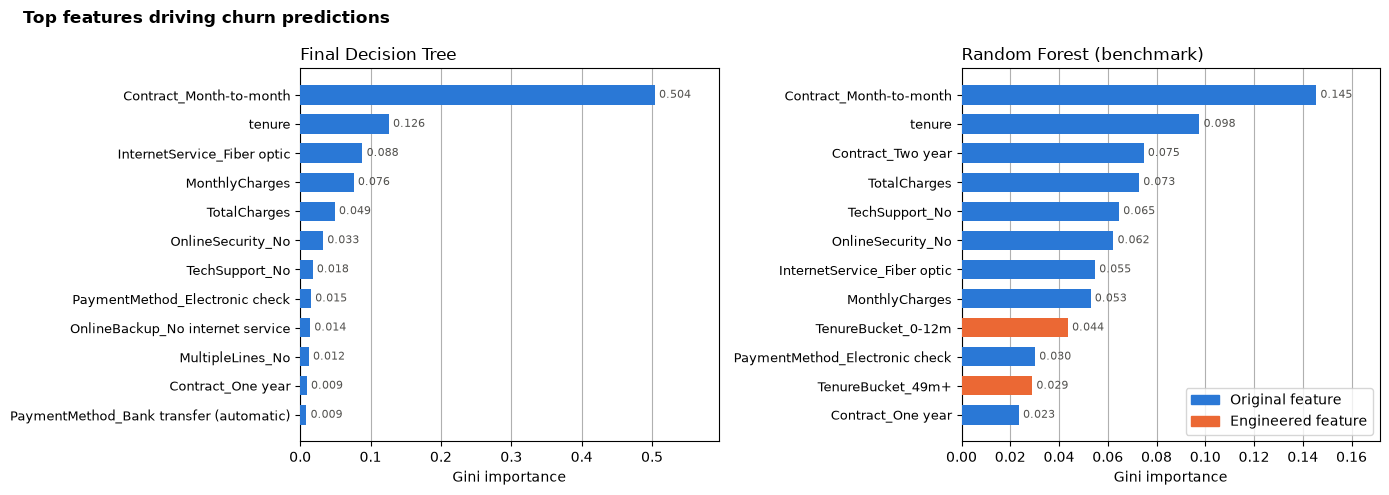

In [40]:
ENG = ["NumAddOnServices", "TenureBucket"]
is_eng = lambda f: any(f.startswith(e) for e in ENG)

forest_imp = pd.Series(forest.named_steps["model"].feature_importances_,
                       index=get_feature_names(forest)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title in [(axes[0], importances, "Final Decision Tree"),
                       (axes[1], forest_imp, "Random Forest (benchmark)")]:
    top = imp.head(12).sort_values()
    ax.barh(np.arange(len(top)), top.values,
            color=[ORANGE if is_eng(f) else BLUE for f in top.index], height=0.66, zorder=3)
    ax.set_yticks(np.arange(len(top)), top.index, fontsize=9)
    for i, v in enumerate(top.values):
        ax.text(v + top.max() * 0.012, i, f"{v:.3f}", va="center", fontsize=8, color=INK_2)
    ax.set_xlim(0, top.max() * 1.18)
    ax.set_xlabel("Gini importance"); ax.set_title(title, loc="left")
    ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
axes[1].legend(handles, ["Original feature", "Engineered feature"], loc="lower right")
fig.suptitle("Top features driving churn predictions", fontsize=12, fontweight="bold",
             x=0.02, ha="left")
plt.tight_layout(); plt.show()

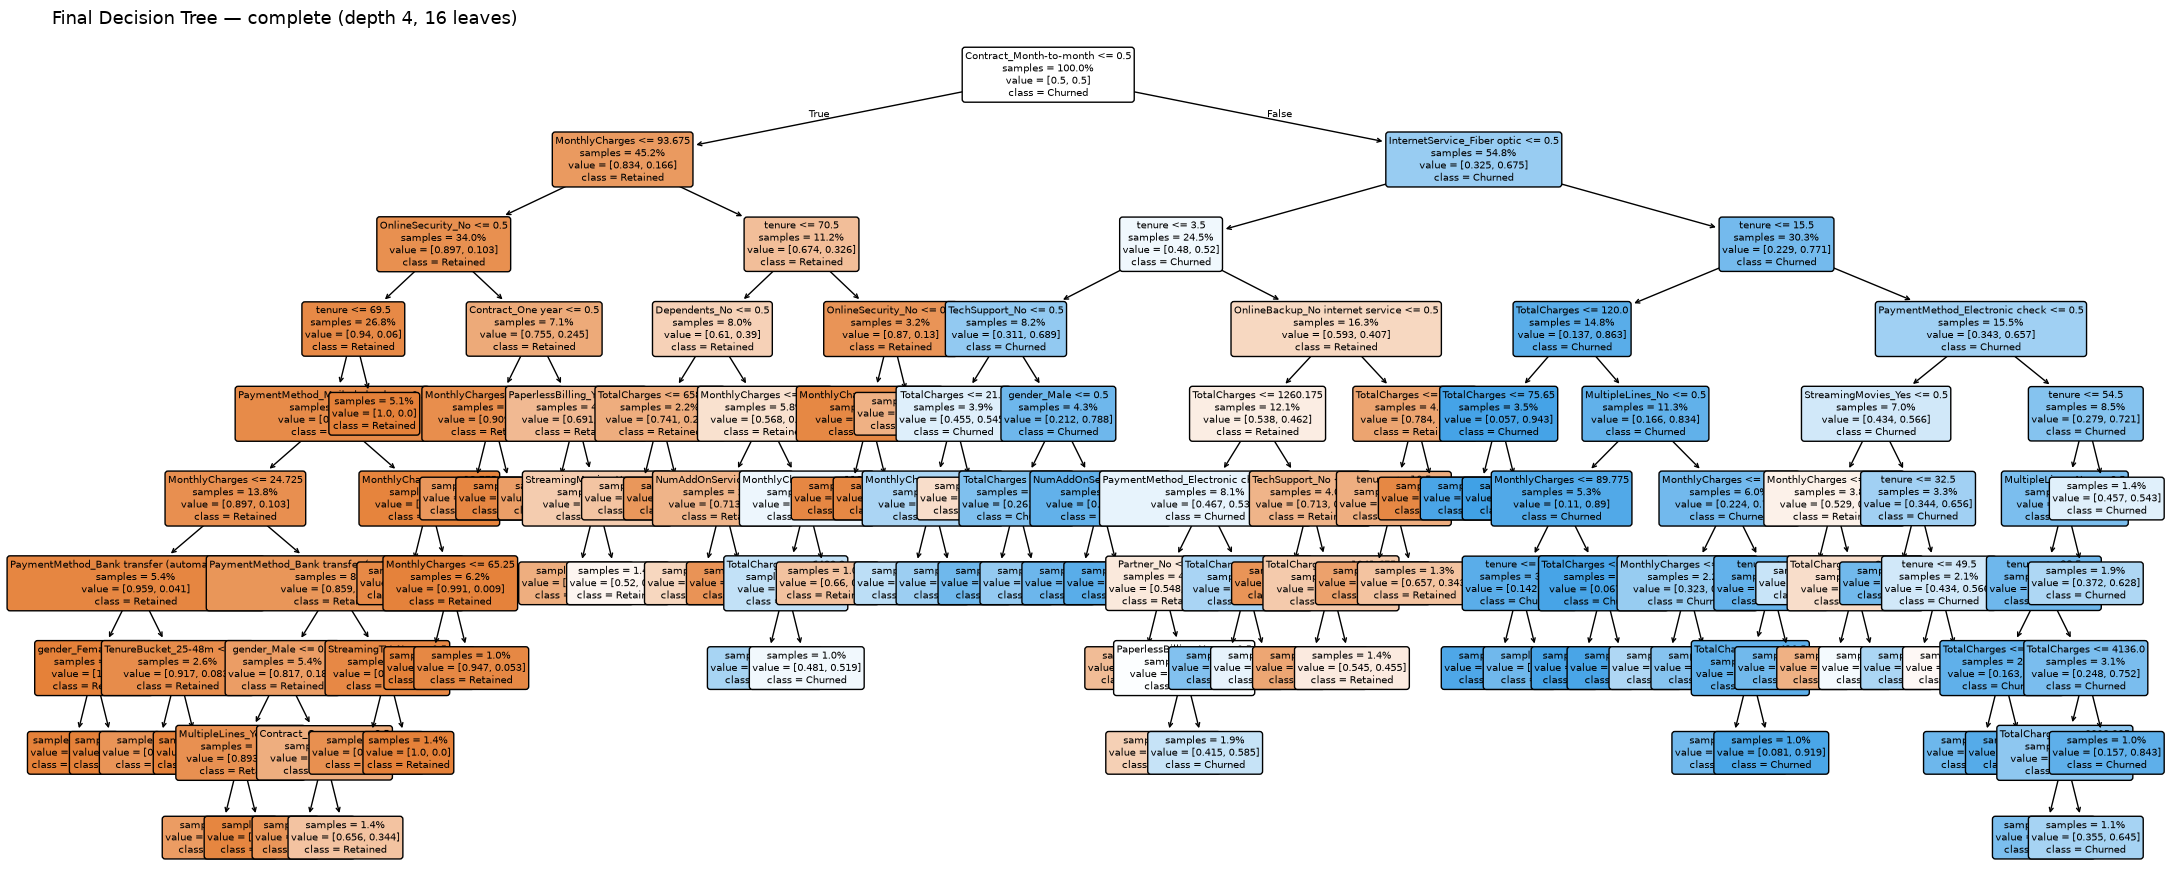

In [41]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(final_tree, feature_names=feature_names,
          class_names=["Retained", "Churned"], filled=True, rounded=True,
          fontsize=7, impurity=False, proportion=True, ax=ax)
ax.set_title("Final Decision Tree — complete (depth 4, 16 leaves)", loc="left", fontsize=13)
plt.tight_layout(); 
plt.show()

## Key findings

1. **Contract type dominates — it alone is ~50% of the model.** The tree's first split is whether the
   customer is on a month-to-month contract, with an importance of **0.504**.
   Everything else is a refinement within that partition.  
2. **Tenure is the second axis (0.126).** Within month-to-month customers, the tree splits on how long
   someone has been around, isolating the first-year cohort as the high-risk group.
3. **Fibre-optic internet (0.088) flags the risky product segment**, consistent with the 41.8% churn
   rate in the EDA section — the premium tier is the leaky one.
4. **Support add-ons act as protection.** `OnlineSecurity = No` (0.033) and `TechSupport = No`
   (0.018) both appear as splits pushing customers into high-risk leaves — the protective pattern
   from EDA, now confirmed as something the model uses.

The highest-risk profile the model describes is : *month-to-month contract, under ~12 months tenure, fibre-optic internet, paying
by electronic check, few or no add-on services.* Customers matching it churn at several times the
base rate, and the model's own structure suggests the three interventions that move them out of that
leaf — **an annual contract offer, automatic payment enrolment, and a bundled security/tech-support
add-on**.

# 7. Deployement

The **entire pipeline** is saved, along with classifier, feature engineering, encoding and the model in one object. 

The API does not need to dupliate the transformation code. Any raw customer record can be parsed exactly as it arrived and the pipeline does the rest.

In [42]:
import joblib

model_path = ROOT/"model"/ "churn_model.pkl"
joblib.dump(FINAL_MODEL, model_path)
print(f"Saved: {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")

Saved: C:\Users\prana\Study\Home Assignment - Technology Band III\customer_churn_project\model\churn_model.pkl  (18.7 KB)
